# F1 Tyre Degradation Model — Bahrain Grand Prix (2022–2025)

**Model:** XGBoost Regressor  
**Inputs:** Driver, Compound, StintLap, LapTime_sec  
**Target:** TyreLife_% (percentage of tyre life remaining)  

**Strategy Logic:**
- **Soft tyres** → life reaches 0% when lap drops 3% below stint baseline pace  
- **Medium tyres** → life reaches 0% when lap drops 4% below stint baseline pace  
- **Hard tyres** → life reaches 0% when lap drops 5% below stint baseline pace  

This model is used downstream by a race strategy simulator to estimate tyre wear and determine optimal pit stop timing.

## Step 1 — Imports & Setup

In [172]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## Step 2 — Data Loading

Load all four Bahrain Grand Prix lap datasets (2022–2025) and concatenate into a single dataframe.

In [173]:

TRACKS = [
    'Australia', 
    'Saudi_Arabia',
    'Hungary',
    'Italy'
]

df_list = []

for track in TRACKS:
    files = sorted(glob.glob(f'datasets/{track}/*_Laps.csv'))
    for f in files:
        temp_df = pd.read_csv(f, low_memory=False)
        year = int(os.path.basename(f).split('_')[0])
        temp_df['Year'] = year
        temp_df['Track'] = track
        df_list.append(temp_df)
        print(f"Loaded {len(temp_df)} laps from {f}")

df = pd.concat(df_list, ignore_index=True)
print(f"\nTotal laps loaded: {len(df)}")
df.head()

Loaded 1045 laps from datasets/Australia\2022_Australia_Laps.csv
Loaded 1003 laps from datasets/Australia\2023_Australia_Laps.csv
Loaded 998 laps from datasets/Australia\2024_Australia_Laps.csv
Loaded 927 laps from datasets/Australia\2025_Australia_Laps.csv
Loaded 820 laps from datasets/Saudi_Arabia\2022_Saudi_Arabia_Laps.csv
Loaded 943 laps from datasets/Saudi_Arabia\2023_Saudi_Arabia_Laps.csv
Loaded 901 laps from datasets/Saudi_Arabia\2024_Saudi_Arabia_Laps.csv
Loaded 898 laps from datasets/Saudi_Arabia\2025_Saudi_Arabia_Laps.csv
Loaded 1383 laps from datasets/Hungary\2022_Hungary_Laps.csv
Loaded 1252 laps from datasets/Hungary\2023_Hungary_Laps.csv
Loaded 1355 laps from datasets/Hungary\2024_Hungary_Laps.csv
Loaded 1368 laps from datasets/Hungary\2025_Hungary_Laps.csv
Loaded 971 laps from datasets/Italy\2022_Italy_Laps.csv
Loaded 958 laps from datasets/Italy\2023_Italy_Laps.csv
Loaded 1008 laps from datasets/Italy\2024_Italy_Laps.csv
Loaded 975 laps from datasets/Italy\2025_Italy_La

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,Year,Track
0,0 days 01:03:43.963000,VER,1,0 days 00:01:30.342000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:18.652000,...,0 days 01:02:13.396000,NaT,1,2.0,NaN,NaN,False,False,2022,Australia
1,0 days 01:05:08.794000,VER,1,0 days 00:01:24.831000,2.0,1.0,NaT,NaT,0 days 00:00:29.719000,0 days 00:00:18.536000,...,0 days 01:03:43.963000,NaT,12,2.0,NaN,NaN,False,True,2022,Australia
2,0 days 01:06:54.969000,VER,1,0 days 00:01:46.175000,3.0,1.0,NaT,NaT,0 days 00:00:29.540000,0 days 00:00:27.197000,...,0 days 01:05:08.794000,NaT,264,2.0,NaN,NaN,False,False,2022,Australia
3,0 days 01:09:09.241000,VER,1,0 days 00:02:14.272000,4.0,1.0,NaT,NaT,0 days 00:00:40.308000,0 days 00:00:30.646000,...,0 days 01:06:54.969000,NaT,4,2.0,NaN,NaN,False,False,2022,Australia
4,0 days 01:11:22.770000,VER,1,0 days 00:02:13.529000,5.0,1.0,NaT,NaT,0 days 00:00:44.387000,0 days 00:00:30.247000,...,0 days 01:09:09.241000,NaT,4,2.0,NaN,NaN,False,False,2022,Australia


## Step 3 — Data Cleaning

1. Convert `LapTime` from timedelta string → seconds  
2. Remove pit laps (`PitInTime` or `PitOutTime` is not null)  
3. Keep only rows with valid lap times  
4. Keep only dry-compound laps (SOFT / MEDIUM / HARD)

In [174]:
# Normalise string 'NaT' artefacts that can appear when CSVs are written from pandas
df = df.replace("NaT", np.nan)

# --- Eligible drivers (same team across 2022-2025) ---
ELIGIBLE_DRIVERS = ['ALB', 'LEC', 'NOR', 'RUS', 'VER']

print(f"Starting rows: {len(df)}")

# 0. Keep only eligible drivers
df = df[df['Driver'].isin(ELIGIBLE_DRIVERS)].copy()
print(f"After filtering eligible drivers: {len(df)}")

# 1. Convert LapTime to seconds
if df["LapTime"].dtype == "object":
    df["LapTime_sec"] = pd.to_timedelta(df["LapTime"], errors="coerce").dt.total_seconds()
else:
    # Already numeric (seconds)
    df["LapTime_sec"] = pd.to_numeric(df["LapTime"], errors="coerce")

# 2. Drop rows with invalid (NaN) lap times
df = df.dropna(subset=["LapTime_sec"])
print(f"After dropping NaN LapTime:    {len(df)}")

# 3. Remove pit-out laps (first lap out of pits)
df = df[df["PitOutTime"].isna()]
print(f"After removing pit-out laps:   {len(df)}")

# 4. Remove pit-in laps (lap driver enters pits)
df = df[df["PitInTime"].isna()]
print(f"After removing pit-in laps:    {len(df)}")

# 5. Keep only dry-compound laps
VALID_COMPOUNDS = ["SOFT", "MEDIUM", "HARD"]
df = df[df["Compound"].isin(VALID_COMPOUNDS)]
print(f"After keeping dry compounds:   {len(df)}")

# 6. Remove the formation / first race lap (LapNumber == 1)
if "LapNumber" in df.columns:
    df = df[df["LapNumber"] > 1]
    print(f"After removing lap 1:          {len(df)}")

print(f"\n✅ Clean dataset: {len(df)} laps")
print(f"Drivers:   {sorted(df['Driver'].unique())}")
print(f"Compounds: {sorted(df['Compound'].unique())}")
print(f"Years:     {sorted(df['Year'].unique())}")

Starting rows: 16805
After filtering eligible drivers: 4300
After dropping NaN LapTime:    4215
After removing pit-out laps:   4109
After removing pit-in laps:    3997
After keeping dry compounds:   3798
After removing lap 1:          3725

✅ Clean dataset: 3725 laps
Drivers:   ['ALB', 'LEC', 'NOR', 'RUS', 'VER']
Compounds: ['HARD', 'MEDIUM', 'SOFT']
Years:     [2022, 2023, 2024, 2025]


C:\Users\roshi\AppData\Local\Temp\ipykernel_8160\1661281759.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("NaT", np.nan)


## Step 4 — Create StintLap Feature

`StintLap` represents the lap number *within* each individual stint (i.e., tyre age in laps).

In [175]:
# Lap number within the current stint — represents tyre age
df["StintLap"] = (
    df.groupby(["Driver", "Stint", "Year","Track"]).cumcount() + 1
)

print("StintLap feature created.")
print(df[["Driver", "Year", "Stint", "LapNumber", "StintLap", "Compound"]].head(12).to_string(index=False))

StintLap feature created.
Driver  Year  Stint  LapNumber  StintLap Compound
   VER  2022    1.0        2.0         1   MEDIUM
   VER  2022    1.0        3.0         2   MEDIUM
   VER  2022    1.0        4.0         3   MEDIUM
   VER  2022    1.0        5.0         4   MEDIUM
   VER  2022    1.0        6.0         5   MEDIUM
   VER  2022    1.0        7.0         6   MEDIUM
   VER  2022    1.0        8.0         7   MEDIUM
   VER  2022    1.0        9.0         8   MEDIUM
   VER  2022    1.0       10.0         9   MEDIUM
   VER  2022    1.0       11.0        10   MEDIUM
   VER  2022    1.0       12.0        11   MEDIUM
   VER  2022    1.0       13.0        12   MEDIUM


## Step 5 — Baseline Compound Pace

Compute the minimum (representative "fresh") lap time for each compound across the entire dataset.  
These baselines define the crossover thresholds for tyre life calculation.

In [176]:
# Only use laps from the first few stint laps to get "fresh tyre" baseline
BASELINE_WINDOW = 5  # first 5 laps of any stint considered as representative pace

baseline_df = df[df["StintLap"] <= BASELINE_WINDOW]
baseline_pace = baseline_df.groupby("Compound")["LapTime_sec"].min()

SOFT_BASELINE   = baseline_pace.get("SOFT",   None)
MEDIUM_BASELINE = baseline_pace.get("MEDIUM", None)
HARD_BASELINE   = baseline_pace.get("HARD",   None)

print("Baseline (minimum) lap times per compound (first 5 laps of each stint):")
print(f"  SOFT   baseline: {SOFT_BASELINE:.3f} s")
print(f"  MEDIUM baseline: {MEDIUM_BASELINE:.3f} s")
print(f"  HARD   baseline: {HARD_BASELINE:.3f} s")

Baseline (minimum) lap times per compound (first 5 laps of each stint):
  SOFT   baseline: 81.038 s
  MEDIUM baseline: 80.504 s
  HARD   baseline: 79.409 s


## Step 6 — Tyre Life Logic & CrossoverLap

For each stint group, find the **crossover lap** where the tyre degrades to the threshold:

| Compound | Crossover Definition |
|----------|----------------------|
| SOFT     | First lap where `LapTime_sec > StintBaseline × 1.03` |
| MEDIUM   | First lap where `LapTime_sec > StintBaseline × 1.04` |
| HARD     | First lap where `LapTime_sec > StintBaseline × 1.05` |


In [177]:
def compute_crossover(group: pd.DataFrame) -> float:
    """
    Determine the crossover lap for a single stint group.
    Returns the stint lap number at which tyre life hits 0%.
    """
    compound = group["Compound"].iloc[0]
    max_stint_lap = group["StintLap"].max()

    # Use the fresh tyre pace of this specific stint to account for slow drivers/track evolution
    stint_baseline = group.loc[group["StintLap"] <= 5, "LapTime_sec"].min()
    if pd.isna(stint_baseline): stint_baseline = group["LapTime_sec"].min()

    if compound == "SOFT":
        threshold = stint_baseline * 1.03
    elif compound == "MEDIUM":
        threshold = stint_baseline * 1.04
    else:  # HARD — use baseline + 5% as degradation threshold
        threshold = stint_baseline * 1.05

    # Smooth lap times using a centered rolling minimum (fastest of [prev, current, next])
    # This filters out anomalous slow laps (e.g. traffic, mistakes) while preserving true degradation trends.
    smoothed_pace = group["LapTime_sec"].rolling(window=3, min_periods=1, center=True).min()

    # Find first stint lap where the smoothed lap time exceeds threshold
    # We also apply a strict 1.07x multiplier cap to ignore Safety Car/VSC laps and spins,
    # which can otherwise defeat the 3-lap smoothing if they last many consecutive laps.
    anomaly_cutoff = threshold * 1.07
    slow_laps = group.loc[(smoothed_pace > threshold) & (group["LapTime_sec"] < anomaly_cutoff), "StintLap"]

    if len(slow_laps) == 0:
        # Tyre never fully degraded during this stint — use last lap as crossover
        return float(max_stint_lap)

    return float(slow_laps.iloc[0])


# Apply per stint group (Driver × Stint × Year uniquely identifies a stint)
crossover_map = (
    df.groupby(["Driver", "Year", "Stint"])
    .apply(compute_crossover, include_groups=False)
    .rename("CrossoverLap")
    .reset_index()
)

df = df.merge(crossover_map, on=["Driver", "Year", "Stint"], how="left")

print(f"CrossoverLap computed for {len(crossover_map)} stints.")
print(crossover_map.head(10).to_string(index=False))

CrossoverLap computed for 66 stints.
Driver  Year  Stint  CrossoverLap
   ALB  2022    1.0           2.0
   ALB  2022    2.0          20.0
   ALB  2022    3.0          17.0
   ALB  2022    4.0          24.0
   ALB  2023    1.0           1.0
   ALB  2023    2.0          35.0
   ALB  2023    3.0          37.0
   ALB  2024    1.0          15.0
   ALB  2024    2.0          34.0
   ALB  2024    3.0          39.0


## Step 7 — Compute TyreLife_% Target

$$\text{TyreLife\%} = 100 \times \left(1 - \frac{\text{StintLap}}{\text{CrossoverLap}}\right)$$

Clipped to **[0, 100]**.

In [178]:
df["TyreLife_%"] = 100.0 * (1.0 - df["StintLap"] / df["CrossoverLap"])
df["TyreLife_%"] = df["TyreLife_%"].clip(lower=0.0, upper=100.0)

print("TyreLife_% summary statistics:")
print(df["TyreLife_%"].describe().round(2))

print(f"\nSample rows:")
sample_cols = ["Driver", "Year", "Stint", "Compound", "StintLap", "CrossoverLap", "LapTime_sec", "TyreLife_%"]
print(df[sample_cols].head(15).to_string(index=False))

TyreLife_% summary statistics:
count    3725.00
mean       45.71
std        32.54
min         0.00
25%        13.79
50%        48.48
75%        75.00
max        97.78
Name: TyreLife_%, dtype: float64

Sample rows:
Driver  Year  Stint Compound  StintLap  CrossoverLap  LapTime_sec  TyreLife_%
   VER  2022    1.0   MEDIUM         1          23.0       84.831   95.652174
   VER  2022    1.0   MEDIUM         2          23.0      106.175   91.304348
   VER  2022    1.0   MEDIUM         3          23.0      134.272   86.956522
   VER  2022    1.0   MEDIUM         4          23.0      133.529   82.608696
   VER  2022    1.0   MEDIUM         5          23.0      144.064   78.260870
   VER  2022    1.0   MEDIUM         6          23.0       84.167   73.913043
   VER  2022    1.0   MEDIUM         7          23.0       83.966   69.565217
   VER  2022    1.0   MEDIUM         8          23.0       83.780   65.217391
   VER  2022    1.0   MEDIUM         9          23.0       83.754   60.869565
   VER

### Visualise Tyre Degradation Curves by Compound

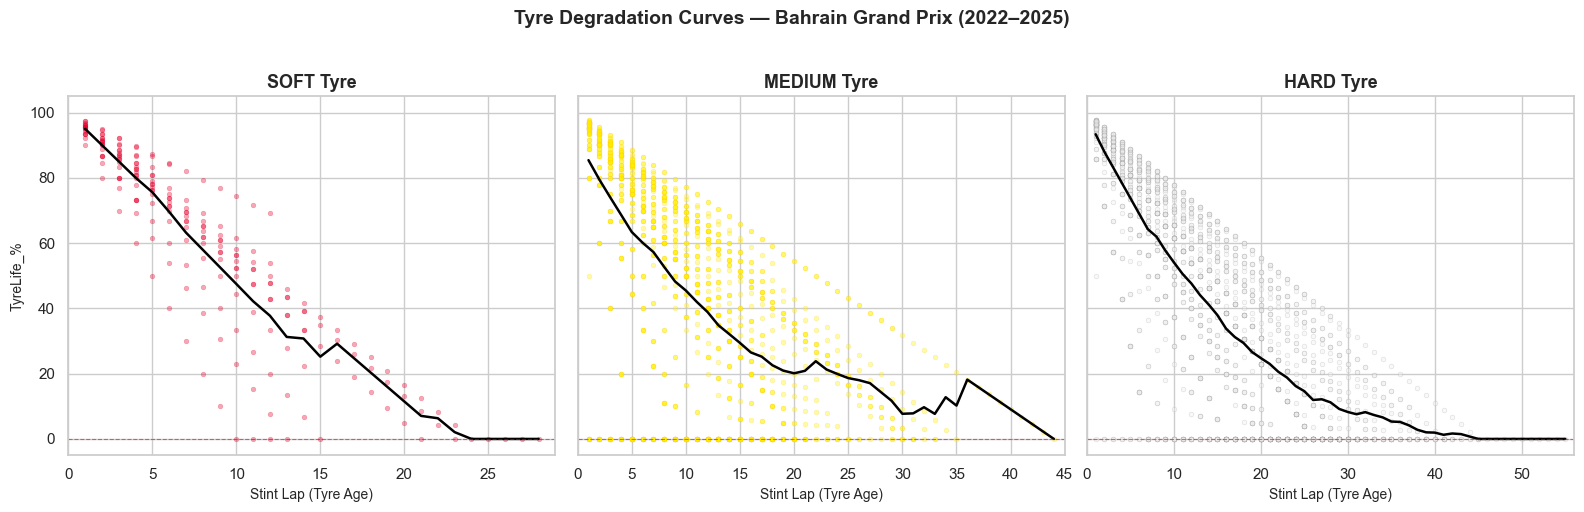

Figure saved → tyre_degradation_curves.png


In [179]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
compound_colors = {"SOFT": "#E8002D", "MEDIUM": "#FFF200", "HARD": "#EBEBEB"}
compound_edge   = {"SOFT": "#E8002D", "MEDIUM": "#FFC906", "HARD": "#888888"}

for ax, compound in zip(axes, ["SOFT", "MEDIUM", "HARD"]):
    sub = df[df["Compound"] == compound]
    ax.scatter(
        sub["StintLap"], sub["TyreLife_%"],
        alpha=0.35, s=12,
        color=compound_colors[compound],
        edgecolors=compound_edge[compound], linewidths=0.3
    )
    # Rolling mean trend
    trend = sub.groupby("StintLap")["TyreLife_%"].mean().reset_index()
    ax.plot(trend["StintLap"], trend["TyreLife_%"], color="black", lw=1.8, label="Mean trend")
    ax.set_title(f"{compound} Tyre", fontsize=13, fontweight="bold")
    ax.set_xlabel("Stint Lap (Tyre Age)", fontsize=10)
    ax.set_ylim(-5, 105)
    ax.set_xlim(0, sub["StintLap"].max() + 1)
    ax.axhline(0, color="red", lw=0.8, linestyle="--", alpha=0.6)

axes[0].set_ylabel("TyreLife_%", fontsize=10)
fig.suptitle("Tyre Degradation Curves — Bahrain Grand Prix (2022–2025)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("tyre_degradation_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → tyre_degradation_curves.png")

## Step 8 — Prepare ML Dataset

Features: `Driver`, `Compound`, `StintLap`, `LapTime_sec`  
Target: `TyreLife_%`

In [180]:
# Drop rows with missing feature values
ml_df = df.dropna(subset=["Driver", "Compound", "StintLap", "LapTime_sec", "TyreLife_%"]).copy()

# --- Label-encode Driver ---
le_driver = LabelEncoder()
ml_df["Driver_encoded"] = le_driver.fit_transform(ml_df["Driver"])

print("Driver encoding:")
for cls, lbl in zip(le_driver.classes_, range(len(le_driver.classes_))):
    print(f"  {cls} → {lbl}")

# --- One-hot encode Compound ---
compound_dummies = pd.get_dummies(ml_df["Compound"], prefix="Compound")
ml_df = pd.concat([ml_df, compound_dummies], axis=1)

# Ensure all three compound columns exist (guard against missing compounds in data)
for col in ["Compound_SOFT", "Compound_MEDIUM", "Compound_HARD"]:
    if col not in ml_df.columns:
        ml_df[col] = 0

FEATURE_COLS = [
    "Driver_encoded",
    "StintLap",
    "LapTime_sec",
    "Compound_SOFT",
    "Compound_MEDIUM",
    "Compound_HARD",
]
TARGET_COL = "TyreLife_%"

print(f"\nFeatures:            {FEATURE_COLS}")
print(f"Target:              {TARGET_COL}")
print(f"Feature matrix shape: {ml_df[FEATURE_COLS].shape}")

Driver encoding:
  ALB → 0
  LEC → 1
  NOR → 2
  RUS → 3
  VER → 4

Features:            ['Driver_encoded', 'StintLap', 'LapTime_sec', 'Compound_SOFT', 'Compound_MEDIUM', 'Compound_HARD']
Target:              TyreLife_%
Feature matrix shape: (3725, 6)


## Step 9 — Train / Test Split (80 / 20)

In [181]:
X = ml_df[FEATURE_COLS]
y = ml_df[TARGET_COL]

# Stratify by Driver to ensure balanced representation
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=ml_df["Driver"]
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")

Training set: 2980 samples
Test set:     745 samples


## Step 10 — Train XGBoost Regressor

In [182]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)

print("✅ Model trained successfully!")

✅ Model trained successfully!


## Step 11 — Model Evaluation

In [183]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 52)
print("  Tyre Degradation Model — Test Set Metrics")
print("=" * 52)
print(f"  MAE  : {mae:.4f} %")
print(f"  MSE  : {mse:.4f} %²")
print(f"  RMSE : {rmse:.4f} %")
print(f"  R²   : {r2:.4f}")
print("=" * 52)

  Tyre Degradation Model — Test Set Metrics
  MAE  : 12.3770 %
  MSE  : 291.9057 %²
  RMSE : 17.0852 %
  R²   : 0.7250


### Per-Driver Evaluation

In [184]:
test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["y_pred"] = y_pred

print("\n  Per-Driver Metrics")
print("-" * 62)
print(f"  {'Driver':<8} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Samples':>8}")
print("-" * 62)

for code_idx in sorted(test_df["Driver_encoded"].unique()):
    driver_name = le_driver.inverse_transform([int(code_idx)])[0]
    mask = test_df["Driver_encoded"] == code_idx
    yt = test_df.loc[mask, "y_true"]
    yp = test_df.loc[mask, "y_pred"]
    d_mae  = mean_absolute_error(yt, yp)
    d_rmse = np.sqrt(mean_squared_error(yt, yp))
    d_r2   = r2_score(yt, yp) if len(yt) > 1 else float("nan")
    print(f"  {driver_name:<8} {d_mae:>8.4f} {d_rmse:>8.4f} {d_r2:>8.4f} {len(yt):>8}")


  Per-Driver Metrics
--------------------------------------------------------------
  Driver        MAE     RMSE       R²  Samples
--------------------------------------------------------------
  ALB       12.6428  19.8621   0.6479      136
  LEC       13.8505  18.2173   0.6894      150
  NOR       11.2040  14.4427   0.7769      160
  RUS       12.5242  17.0862   0.7211      152
  VER       11.7521  15.7116   0.7454      147


### Per-Compound Evaluation

In [185]:
# Recover compound label for test rows
test_df["Compound"] = ml_df.loc[X_test.index, "Compound"].values

print("\n  Per-Compound Metrics")
print("-" * 62)
print(f"  {'Compound':<10} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Samples':>8}")
print("-" * 62)

for compound in ["SOFT", "MEDIUM", "HARD"]:
    mask = test_df["Compound"] == compound
    if mask.sum() == 0:
        continue
    yt = test_df.loc[mask, "y_true"]
    yp = test_df.loc[mask, "y_pred"]
    c_mae  = mean_absolute_error(yt, yp)
    c_rmse = np.sqrt(mean_squared_error(yt, yp))
    c_r2   = r2_score(yt, yp) if len(yt) > 1 else float("nan")
    print(f"  {compound:<10} {c_mae:>8.4f} {c_rmse:>8.4f} {c_r2:>8.4f} {len(yt):>8}")


  Per-Compound Metrics
--------------------------------------------------------------
  Compound        MAE     RMSE       R²  Samples
--------------------------------------------------------------
  SOFT         7.5685  11.8236   0.8462       47
  MEDIUM      12.9622  18.3201   0.6798      251
  HARD        12.5541  16.8330   0.7312      447


### Sample Prediction Table

In [186]:
print("\n  Sample Predictions")
print("-" * 80)
print(f"  {'Driver':<8} | {'Compound':<8} | {'StintLap':>8} | {'LapTime(s)':>10} | {'Actual %':>9} | {'Pred %':>9}")
print("-" * 80)

sample_test = test_df.sample(n=min(15, len(test_df)), random_state=42)
for idx, row in sample_test.iterrows():
    driver_name = le_driver.inverse_transform([int(row["Driver_encoded"])])[0]
    compound    = row["Compound"]
    stint_lap   = int(row["StintLap"])
    laptime     = row["LapTime_sec"]
    y_act       = row["y_true"]
    y_pr        = row["y_pred"]
    print(f"  {driver_name:<8} | {compound:<8} | {stint_lap:>8} | {laptime:>10.3f} | {y_act:>9.2f} | {y_pr:>9.2f}")


  Sample Predictions
--------------------------------------------------------------------------------
  Driver   | Compound | StintLap | LapTime(s) |  Actual % |    Pred %
--------------------------------------------------------------------------------
  NOR      | HARD     |       18 |     93.874 |     59.09 |     37.07
  NOR      | HARD     |       15 |     87.567 |     66.67 |     36.80
  VER      | MEDIUM   |       22 |     82.782 |     37.14 |     26.79
  NOR      | MEDIUM   |        4 |     82.827 |     86.67 |     87.48
  LEC      | HARD     |       15 |     82.219 |     25.00 |     39.84
  RUS      | HARD     |       19 |     84.748 |     38.71 |     25.09
  LEC      | HARD     |       33 |     80.260 |      0.00 |     13.10
  ALB      | HARD     |       25 |     93.728 |      7.41 |     12.02
  RUS      | HARD     |       11 |     92.893 |     62.07 |     44.30
  ALB      | SOFT     |        7 |     83.433 |     82.05 |     73.92
  RUS      | HARD     |       22 |     93.387 

### Feature Importance

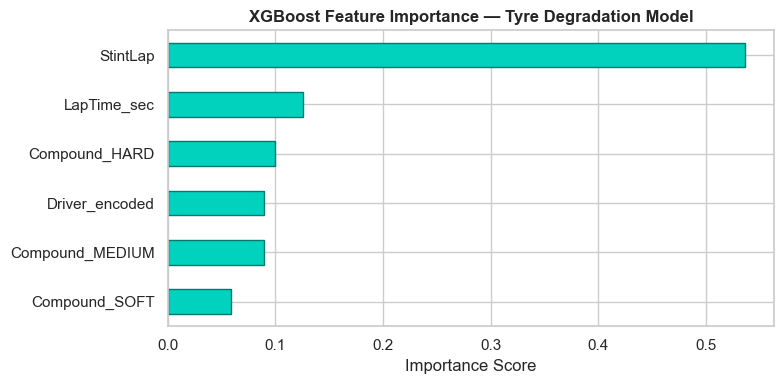

Figure saved → feature_importance.png


In [187]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind="barh", ax=ax, color="#00D2BE", edgecolor="#007A6E")
ax.set_title("XGBoost Feature Importance — Tyre Degradation Model", fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → feature_importance.png")

### Actual vs Predicted Scatter Plot

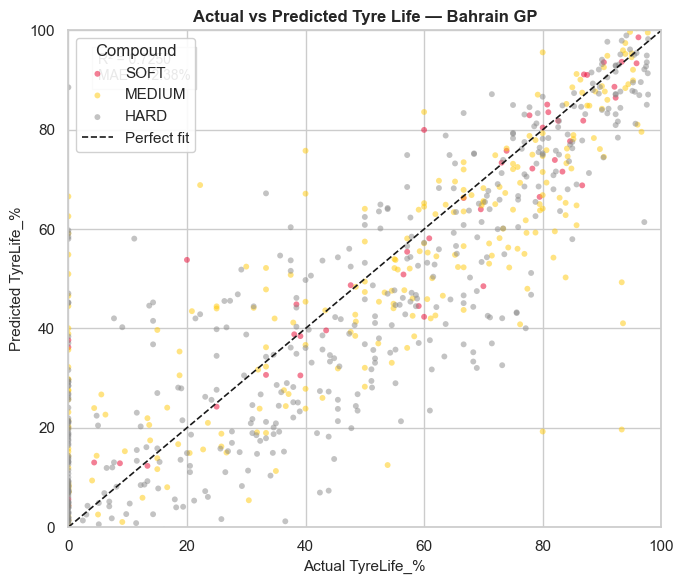

Figure saved → actual_vs_predicted.png


In [188]:
fig, ax = plt.subplots(figsize=(7, 6))

compound_colors_map = {"SOFT": "#E8002D", "MEDIUM": "#FFC906", "HARD": "#888888"}
for compound in ["SOFT", "MEDIUM", "HARD"]:
    mask = test_df["Compound"] == compound
    ax.scatter(
        test_df.loc[mask, "y_true"],
        test_df.loc[mask, "y_pred"],
        alpha=0.5, s=18,
        color=compound_colors_map[compound],
        label=compound, edgecolors="none"
    )

# Perfect prediction line
lims = [0, 100]
ax.plot(lims, lims, "k--", lw=1.2, label="Perfect fit")
ax.set_xlim(*lims)
ax.set_ylim(*lims)
ax.set_xlabel("Actual TyreLife_%", fontsize=11)
ax.set_ylabel("Predicted TyreLife_%", fontsize=11)
ax.set_title("Actual vs Predicted Tyre Life — Bahrain GP", fontweight="bold")
ax.legend(title="Compound", framealpha=0.9)
ax.text(5, 90, f"R² = {r2:.4f}\nMAE = {mae:.2f}%", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="#cccccc"))

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → actual_vs_predicted.png")

## Step 12 — Save the Trained Model

The model and driver encoder are saved using `joblib` for use in the race strategy simulator.

In [189]:
MODEL_PATH   = "bahrain_tyre_degradation_model.joblib"
ENCODER_PATH = "bahrain_tyre_le_driver.joblib"
META_PATH    = "bahrain_tyre_model_meta.joblib"

joblib.dump(model, MODEL_PATH)
joblib.dump(le_driver, ENCODER_PATH)

model_meta = {
    "feature_cols": FEATURE_COLS,
    "target_col": TARGET_COL,
    "baseline_pace": {
        "SOFT":   SOFT_BASELINE,
        "MEDIUM": MEDIUM_BASELINE,
        "HARD":   HARD_BASELINE,
    },
    "drivers": list(le_driver.classes_),
    "compounds": ["SOFT", "MEDIUM", "HARD"],
    "metrics": {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2},
}
joblib.dump(model_meta, META_PATH)

print(f"✅ Model saved       → {MODEL_PATH}")
print(f"✅ Driver encoder    → {ENCODER_PATH}")
print(f"✅ Model metadata    → {META_PATH}")

✅ Model saved       → bahrain_tyre_degradation_model.joblib
✅ Driver encoder    → bahrain_tyre_le_driver.joblib
✅ Model metadata    → bahrain_tyre_model_meta.joblib


## Step 13 — Inference Helper

A reusable function to load the saved model and predict `TyreLife_%` for a given lap.  
This is the interface consumed by the race strategy simulator.

In [190]:
def predict_tyre_life(
    driver: str,
    compound: str,
    stint_lap: int,
    laptime_sec: float,
    model_path: str = MODEL_PATH,
    encoder_path: str = ENCODER_PATH,
) -> float:
    """
    Predict TyreLife_% for a single lap.

    Parameters
    ----------
    driver      : Driver code, e.g. 'VER', 'LEC'
    compound    : 'SOFT', 'MEDIUM', or 'HARD'
    stint_lap   : Lap number within the current stint (1-indexed)
    laptime_sec : Lap time in seconds

    Returns
    -------
    float : Predicted TyreLife_% (0–100)
    """
    _model   = joblib.load(model_path)
    _le      = joblib.load(encoder_path)

    driver_enc = _le.transform([driver])[0]

    row = {
        "Driver_encoded":   driver_enc,
        "StintLap":         stint_lap,
        "LapTime_sec":      laptime_sec,
        "Compound_SOFT":    1 if compound == "SOFT"   else 0,
        "Compound_MEDIUM":  1 if compound == "MEDIUM" else 0,
        "Compound_HARD":    1 if compound == "HARD"   else 0,
    }

    X_infer = pd.DataFrame([row])
    pred = float(_model.predict(X_infer)[0])
    return round(np.clip(pred, 0.0, 100.0), 2)


# --- Demonstration ---
print("=" * 52)
print("  Inference Demo")
print("=" * 52)

demo_cases = [
    ("VER", "SOFT",   5,  92.5),
    ("VER", "SOFT",  18,  94.8),
    ("LEC", "MEDIUM",10,  93.1),
    ("LEC", "MEDIUM",28,  95.3),
    ("HAM", "HARD",  15,  93.9),
    ("HAM", "HARD",  35,  95.0),
]

print(f"  {'Driver':<8} {'Compound':<8} {'StintLap':>8} {'LapTime':>10} {'TyreLife%':>11}")
print("-" * 52)
for driver, compound, stint_lap, laptime in demo_cases:
    try:
        pred = predict_tyre_life(driver, compound, stint_lap, laptime)
        print(f"  {driver:<8} {compound:<8} {stint_lap:>8} {laptime:>10.3f} {pred:>10.2f}%")
    except Exception as e:
        print(f"  {driver:<8} {compound:<8} {stint_lap:>8} {laptime:>10.3f}   [Error: {e}]")

  Inference Demo
  Driver   Compound StintLap    LapTime   TyreLife%
----------------------------------------------------
  VER      SOFT            5     92.500      86.49%
  VER      SOFT           18     94.800      19.32%
  LEC      MEDIUM         10     93.100      40.09%
  LEC      MEDIUM         28     95.300       0.00%
  HAM      HARD           15     93.900   [Error: y contains previously unseen labels: 'HAM']
  HAM      HARD           35     95.000   [Error: y contains previously unseen labels: 'HAM']
